In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.stats.proportion as proportion

# Make project-level src modules importable when the notebook is run from notebooks/.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.cleaning import load_data

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
df = load_data("../data/marketing_AB.csv")

print(f"Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Dataset loaded successfully.
Rows: 588,101
Columns: 7


In [3]:
df.head()


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [5]:
print("Unique values:", df["Unnamed: 0"].nunique())
print("Minimum:", df["Unnamed: 0"].min())
print("Maximum:", df["Unnamed: 0"].max())

print("\nFirst 10 values:")
print(df["Unnamed: 0"].head(10).tolist())

print("\nLast 10 values:")
print(df["Unnamed: 0"].tail(10).tolist())

Unique values: 588101
Minimum: 0
Maximum: 588100

First 10 values:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Last 10 values:
[588091, 588092, 588093, 588094, 588095, 588096, 588097, 588098, 588099, 588100]


In [6]:
print("Test Group Values:")
print(df["test group"].value_counts())

print("\nMost Ads Day Values:")
print(df["most ads day"].value_counts())

print("\nConverted Values:")
print(df["converted"].value_counts())

Test Group Values:
test group
ad     564577
psa     23524
Name: count, dtype: int64

Most Ads Day Values:
most ads day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64

Converted Values:
converted
False    573258
True      14843
Name: count, dtype: int64


In [7]:
group_distribution = (
    df["test group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

conversion_distribution = (
    df["converted"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Test Group Distribution (%)")
print(group_distribution)

print("\nConversion Distribution (%)")
print(conversion_distribution)

Test Group Distribution (%)
test group
ad     96.0
psa     4.0
Name: proportion, dtype: float64

Conversion Distribution (%)
converted
False    97.48
True      2.52
Name: proportion, dtype: float64


In [8]:
conversion_by_group = (
    df.groupby("test group")["converted"]
    .agg(
        users="count",
        conversions="sum",
        conversion_rate="mean"
    )
)

conversion_by_group["conversion_rate"] = (
    conversion_by_group["conversion_rate"] * 100
).round(3)

conversion_by_group

,users,conversions,conversion_rate
test group,,,
ad,564577,14423,2.555
psa,23524,420,1.785


In [9]:

df["total ads"].describe()

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64

In [10]:
print("Unique values:", df["total ads"].nunique())
print("Median:", df["total ads"].median())
print("IQR:", df["total ads"].quantile(0.75) - df["total ads"].quantile(0.25))
print("Maximum:", df["total ads"].max())

Unique values: 807


Median: 13.0
IQR: 23.0
Maximum: 2065


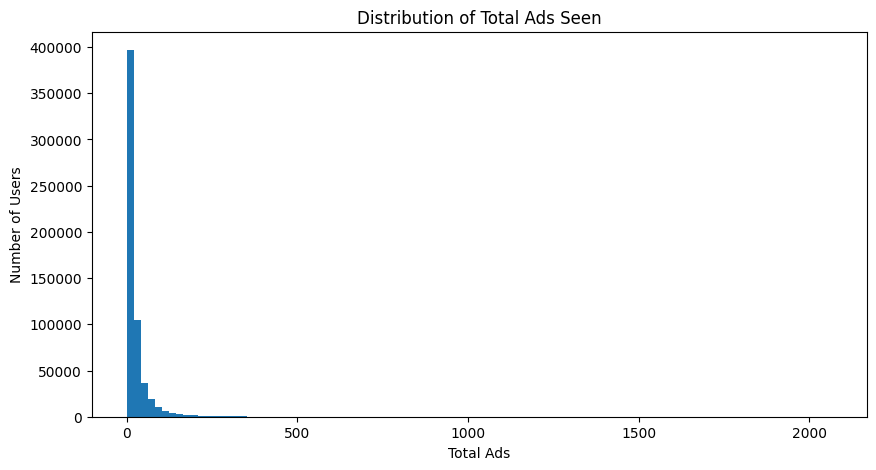

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(df["total ads"], bins=100)

plt.title("Distribution of Total Ads Seen")
plt.xlabel("Total Ads")
plt.ylabel("Number of Users")
plt.show()


In [12]:
hour_distribution = (
    df["most ads hour"]
    .value_counts()
    .sort_index()
)

hour_distribution

most ads hour
0      5536
1      4802
2      5333
3      2679
4       722
5       765
6      2068
7      6405
8     17627
9     31004
10    38939
11    46210
12    47298
13    47655
14    45648
15    44683
16    37567
17    34988
18    32323
19    30352
20    28923
21    29976
22    26432
23    20166
Name: count, dtype: int64

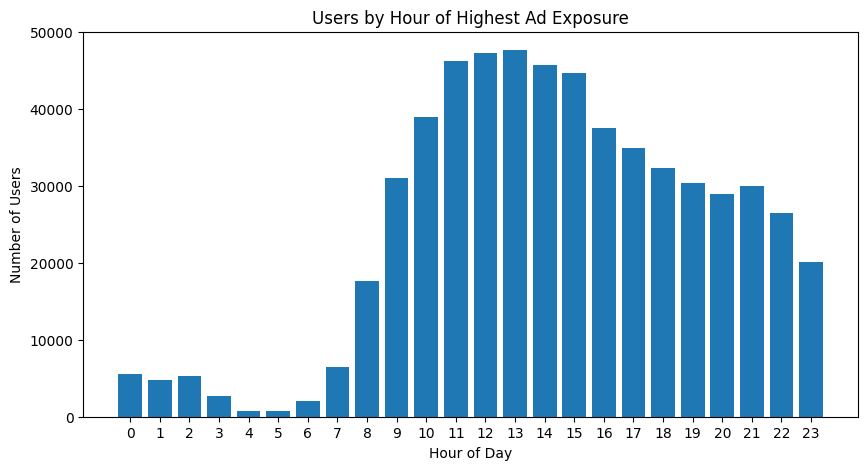

In [13]:
plt.figure(figsize=(10, 5))

plt.bar(hour_distribution.index, hour_distribution.values)

plt.title("Users by Hour of Highest Ad Exposure")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Users")
plt.xticks(range(24))
plt.show()


In [14]:
day_distribution = (
    df["most ads day"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

day_distribution

most ads day
Monday       87073
Tuesday      77479
Wednesday    80908
Thursday     82982
Friday       92608
Saturday     81660
Sunday       85391
Name: count, dtype: int64

In [15]:
duplicate_users = df["user id"].duplicated().sum()

print(f"Duplicate user rows: {duplicate_users:,}")
print(f"Unique users: {df['user id'].nunique():,}")
print(f"Total rows: {len(df):,}")

Duplicate user rows: 0
Unique users: 588,101
Total rows: 588,101


In [16]:
user_counts = df["user id"].value_counts()

user_counts[user_counts > 1].head(20)

Series([], Name: count, dtype: int64)

In [17]:
print("User ID range:")
print(f"Minimum: {df['user id'].min():,}")
print(f"Maximum: {df['user id'].max():,}")

print("\nTotal Ads range:")
print(f"Minimum: {df['total ads'].min():,}")
print(f"Maximum: {df['total ads'].max():,}")

print("\nMost Ads Hour range:")
print(f"Minimum: {df['most ads hour'].min()}")
print(f"Maximum: {df['most ads hour'].max()}")

User ID range:
Minimum: 900,000
Maximum: 1,654,483

Total Ads range:
Minimum: 1
Maximum: 2,065

Most Ads Hour range:
Minimum: 0
Maximum: 23


In [18]:
print("Potentially invalid values:")

print("total_ads <= 0:", (df["total ads"] <= 0).sum())
print("most_ads_hour < 0:", (df["most ads hour"] < 0).sum())
print("most_ads_hour > 23:", (df["most ads hour"] > 23).sum())

Potentially invalid values:
total_ads <= 0: 0
most_ads_hour < 0: 0
most_ads_hour > 23: 0


In [19]:
exposure_by_group = (
    df.groupby("test group")["total ads"]
    .agg(
        users="count",
        mean="mean",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max="max"
    )
    .round(2)
)

exposure_by_group

,users,mean,median,q1,q3,max
test group,,,,,,
ad,564577,24.82,13.0,4.0,27.0,2065
psa,23524,24.76,12.0,4.0,26.0,907


In [20]:
conversion_by_day = (
    df.groupby(["most ads day", "test group"])["converted"]
    .mean()
    .mul(100)
    .round(3)
    .unstack()
)

conversion_by_day

test group,ad,psa
most ads day,,
Friday,2.246,1.630
Monday,3.324,2.256
Saturday,2.131,1.400
Sunday,2.462,2.059
Thursday,2.164,2.023
Tuesday,3.044,1.445
Wednesday,2.536,1.576


## Initial Data Quality Observations

- The dataset contains 588,101 user-level observations and 7 columns.
- `Unnamed: 0` is a sequential index column and does not appear to contain analytical information.
- No missing values were identified.
- No duplicate `user_id` values were identified.
- `test_group` contains the expected `ad` and `psa` groups.
- `most_ads_day` contains all seven days of the week.
- `most_ads_hour` contains values within the valid 0–23 hour range.
- `total_ads` contains no non-positive values but is strongly right-skewed, with a maximum of 2,065.
- The observed experiment allocation is approximately 96% Ad and 4% PSA. This imbalance requires formal Sample Ratio Mismatch (SRM) validation and should not be judged solely from the observed proportions.
- The observed conversion rate is higher in the Ad group than the PSA group, but statistical significance and practical significance have not yet been evaluated.